In [8]:
# %%
# IMPORTS
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# %%
# USER CONFIG
DATA_DIR = r"D:\lecture\PTIT\20251\IntSys\Viet Nam Stock Market Data"  # <- chỉnh đường dẫn nếu cần
FILES = ["HOSEVN30M30.csv", "HOSEVN100M30.csv", "HOSEVNINDEXM30.csv"]
TARGET_COLUMN = 'close'  # giả sử các file có cột 'Close'
SEQUENCE_LENGTH = 60  # dùng 60 time-steps
TEST_RATIO = 0.2
RANDOM_SEED = 42
BATCH_SIZE = 32
EPOCHS = 100

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# %%
# HELPER FUNCTIONS

def load_and_merge(files, data_dir=DATA_DIR, target_col=TARGET_COLUMN):
    """Đọc các file và hợp nhất theo chỉ mục thời gian nếu có. Nếu không có index, đọc riêng từng file.
    Trả về DataFrame dictionary keyed by filename (không gộp dữ liệu lại)
    """
    dfs = {}
    for f in files:
        path = os.path.join(data_dir, f)
        if not os.path.exists(path):
            raise FileNotFoundError(f"Không tìm thấy file: {path}")
        df = pd.read_csv(path, parse_dates=True, infer_datetime_format=True)
        # nếu có cột Date hoặc Time, hãy chuyển sang datetime index
        if 'Date' in df.columns:
            df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
            df = df.sort_values('Date').set_index('Date')
        elif 'date' in df.columns:
            df['date'] = pd.to_datetime(df['date'], errors='coerce')
            df = df.sort_values('date').set_index('date')
        dfs[f] = df
    return dfs


def create_sequences(values, seq_len=SEQUENCE_LENGTH):
    X, y = [], []
    for i in range(len(values) - seq_len):
        X.append(values[i:i+seq_len])
        y.append(values[i+seq_len])
    return np.array(X), np.array(y)


def train_val_test_split(X, y, test_ratio=TEST_RATIO):
    n = len(X)
    test_size = int(n * test_ratio)
    train_size = n - test_size
    X_train, y_train = X[:train_size], y[:train_size]
    X_test, y_test = X[train_size:], y[train_size:]
    # further split train into train+val
    val_size = int(0.1 * len(X_train))
    if val_size == 0:
        val_size = 1
    X_val, y_val = X_train[-val_size:], y_train[-val_size:]
    X_train, y_train = X_train[:-val_size], y_train[:-val_size]
    return X_train, y_train, X_val, y_val, X_test, y_test


def plot_history(hist, title='Training History'):
    plt.figure(figsize=(10,5))
    plt.plot(hist.history['loss'], label='train_loss')
    if 'val_loss' in hist.history:
        plt.plot(hist.history['val_loss'], label='val_loss')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


def evaluate_and_report(model, X_test, y_test, scaler=None):
    y_pred = model.predict(X_test)
    if scaler is not None:
        # y_pred and y_test are scaled if scaler used on target; inverse
        y_pred = scaler.inverse_transform(y_pred.reshape(-1,1)).flatten()
        y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()
    else:
        y_test_unscaled = y_test
    rmse = np.sqrt(mean_squared_error(y_test_unscaled, y_pred))
    mae = mean_absolute_error(y_test_unscaled, y_pred)
    print(f"RMSE: {rmse:.4f}, MAE: {mae:.4f}")
    return y_test_unscaled, y_pred, rmse, mae

# %%
# LOAD DATA
try:
    dfs = load_and_merge(FILES, DATA_DIR)
except FileNotFoundError as e:
    print(str(e))
    print("Hãy kiểm tra biến DATA_DIR và tên file. Dừng ở đây.")
    # Kết thúc cell nếu file không tồn tại

# %%
# CHOOSE ONE DATASET TO DEMONSTRATE (ví dụ dùng HOSEVNINDEXM30.csv nếu có)
sample_file = None
for f in FILES:
    if 'INDEX' in f.upper():
        sample_file = f
        break
if sample_file is None:
    sample_file = FILES[0]

print(f"Sử dụng file mẫu: {sample_file}")
df = dfs[sample_file]
print(df.head())

# %%
# PREPROCESS: chọn target, fillna, scale
if TARGET_COLUMN not in df.columns:
    # tìm 1 cột giá gần giống
    possible = [c for c in df.columns if 'close' in c.lower()]
    if len(possible) > 0:
        TARGET_COLUMN = possible[0]
    else:
        raise ValueError('Không tìm thấy cột Close trong file dữ liệu.')

series = df[[TARGET_COLUMN]].copy()
series = series.dropna()

scaler = MinMaxScaler(feature_range=(0,1))
scaled = scaler.fit_transform(series.values)

# %%
# Tạo sequence
X, y = create_sequences(scaled, seq_len=SEQUENCE_LENGTH)
print('Shapes:', X.shape, y.shape)

# reshape X to (samples, timesteps, features)
# nếu chỉ 1 feature thì shape already (n, seq_len, 1) if created appropriately
if X.ndim == 2:
    X = X.reshape((X.shape[0], X.shape[1], 1))

X_train, y_train, X_val, y_val, X_test, y_test = train_val_test_split(X, y)
print('Split shapes:', X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape)


Sử dụng file mẫu: HOSEVNINDEXM30.csv
         time    open    high     low   close  55EMA  89EMA  200EMA  Plot
0  1451872800  579.03  579.46  578.33  579.28    NaN    NaN     NaN   NaN
1  1451874600  579.48  579.97  578.99  579.67    NaN    NaN     NaN   NaN
2  1451876400  579.55  579.55  578.14  578.52    NaN    NaN     NaN   NaN
3  1451878200  579.34  579.34  577.76  577.94    NaN    NaN     NaN   NaN
4  1451880000  577.84  579.32  577.44  579.32    NaN    NaN     NaN   NaN
Shapes: (22104, 60, 1) (22104, 1)
Split shapes: (15916, 60, 1) (15916, 1) (1768, 60, 1) (1768, 1) (4420, 60, 1) (4420, 1)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_14 (SimpleRNN)            │ (None, 60, 64)              │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 60, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_15 (SimpleRNN)            │ (None, 60, 64)              │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_16 (SimpleRNN)            │ (None, 60, 64)              │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 60, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_17 (SimpleRNN)            │ (None, 32)                  │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,953 (101.38 KB)

 Trainable params: 25,697 (100.38 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/100

Epoch 1: val_loss improved from None to 0.00511, saving model to best_rnn.h5


498/498 - 31s - 62ms/step - loss: 0.0147 - val_loss: 0.0051 - learning_rate: 1.0000e-03
Epoch 2/100

Epoch 2: val_loss improved from 0.00511 to 0.00148, saving model to best_rnn.h5


498/498 - 20s - 40ms/step - loss: 0.0043 - val_loss: 0.0015 - learning_rate: 1.0000e-03
Epoch 3/100

Epoch 3: val_loss did not improve from 0.00148
498/498 - 21s - 42ms/step - loss: 0.0026 - val_loss: 0.0100 - learning_rate: 1.0000e-03
Epoch 4/100

Epoch 4: val_loss improved from 0.00148 to 0.00040, saving model to best_rnn.h5


498/498 - 20s - 41ms/step - loss: 0.0019 - val_loss: 4.0330e-04 - learning_rate: 1.0000e-03
Epoch 5/100

Epoch 5: val_loss did not improve from 0.00040
498/498 - 23s - 46ms/step - loss: 0.0013 - val_loss: 0.0025 - learning_rate: 1.0000e-03
Epoch 6/100

Epoch 6: val_loss did not improve from 0.00040
498/498 - 38s - 77ms/step - loss: 0.0012 - val_loss: 0.0034 - learning_rate: 1.0000e-03
Epoch 7/100

Epoch 7: val_loss did not improve from 0.00040
498/498 - 21s - 43ms/step - loss: 0.0010 - val_loss: 0.0053 - learning_rate: 1.0000e-03
Epoch 8/100

Epoch 8: val_loss did not improve from 0.00040
498/498 - 18s - 37ms/step - loss: 0.0042 - val_loss: 0.0015 - learning_rate: 1.0000e-03
Epoch 9/100

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 9: val_loss did not improve from 0.00040
498/498 - 21s - 42ms/step - loss: 0.0023 - val_loss: 0.0050 - learning_rate: 1.0000e-03
Epoch 10/100

Epoch 10: val_loss did not improve from 0.00040
498/498 - 20s - 40ms/step - l

498/498 - 21s - 43ms/step - loss: 0.0030 - val_loss: 1.6979e-04 - learning_rate: 5.0000e-04
Epoch 15/100

Epoch 15: val_loss did not improve from 0.00017
498/498 - 43s - 87ms/step - loss: 0.0018 - val_loss: 3.0451e-04 - learning_rate: 5.0000e-04
Epoch 16/100

Epoch 16: val_loss did not improve from 0.00017
498/498 - 23s - 47ms/step - loss: 0.0013 - val_loss: 0.0042 - learning_rate: 5.0000e-04
Epoch 17/100

Epoch 17: val_loss did not improve from 0.00017
498/498 - 38s - 77ms/step - loss: 0.0010 - val_loss: 0.0035 - learning_rate: 5.0000e-04
Epoch 18/100

Epoch 18: val_loss did not improve from 0.00017
498/498 - 40s - 80ms/step - loss: 8.2345e-04 - val_loss: 7.2319e-04 - learning_rate: 5.0000e-04
Epoch 19/100

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 19: val_loss did not improve from 0.00017
498/498 - 22s - 43ms/step - loss: 7.9527e-04 - val_loss: 7.5183e-04 - learning_rate: 5.0000e-04
Epoch 20/100

Epoch 20: val_loss did not improve from 0.0001

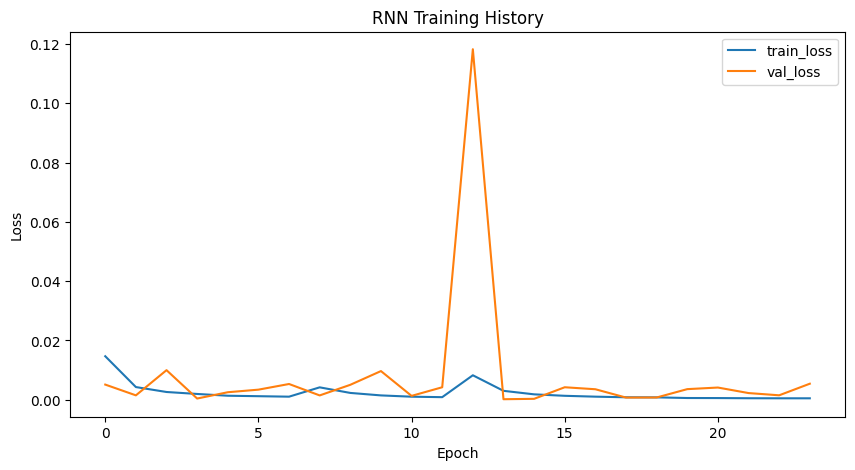

139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step
RMSE: 8.2541, MAE: 6.4108


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                       │ (None, 60, 128)             │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 60, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_15 (LSTM)                       │ (None, 60, 64)              │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_16 (LSTM)                       │ (None, 60, 64)              │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 60, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_17 (LSTM)                       │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 163,777 (639.75 KB)

 Trainable params: 163,393 (638.25 KB)

...

Epoch 1/100

Epoch 1: val_loss improved from None to 0.02660, saving model to best_lstm.h5


498/498 - 61s - 122ms/step - loss: 0.0075 - val_loss: 0.0266 - learning_rate: 1.0000e-03
Epoch 2/100

Epoch 2: val_loss improved from 0.02660 to 0.00592, saving model to best_lstm.h5


498/498 - 49s - 98ms/step - loss: 0.0024 - val_loss: 0.0059 - learning_rate: 1.0000e-03
Epoch 3/100

Epoch 3: val_loss improved from 0.00592 to 0.00319, saving model to best_lstm.h5


498/498 - 46s - 92ms/step - loss: 0.0017 - val_loss: 0.0032 - learning_rate: 1.0000e-03
Epoch 4/100

Epoch 4: val_loss improved from 0.00319 to 0.00072, saving model to best_lstm.h5


498/498 - 46s - 92ms/step - loss: 0.0012 - val_loss: 7.1650e-04 - learning_rate: 1.0000e-03
Epoch 5/100

Epoch 5: val_loss did not improve from 0.00072
498/498 - 46s - 92ms/step - loss: 9.2472e-04 - val_loss: 0.0017 - learning_rate: 1.0000e-03
Epoch 6/100

Epoch 6: val_loss did not improve from 0.00072
498/498 - 46s - 91ms/step - loss: 0.0010 - val_loss: 0.0033 - learning_rate: 1.0000e-03
Epoch 7/100

Epoch 7: val_loss did not improve from 0.00072
498/498 - 47s - 94ms/step - loss: 8.2461e-04 - val_loss: 0.0032 - learning_rate: 1.0000e-03
Epoch 8/100

Epoch 8: val_loss did not improve from 0.00072
498/498 - 46s - 92ms/step - loss: 5.6609e-04 - val_loss: 0.0013 - learning_rate: 1.0000e-03
Epoch 9/100

Epoch 9: val_loss did not improve from 0.00072
498/498 - 46s - 93ms/step - loss: 5.4259e-04 - val_loss: 0.0013 - learning_rate: 1.0000e-03
Epoch 10/100

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 10: val_loss did not improve from 0.00072
498/498 - 45

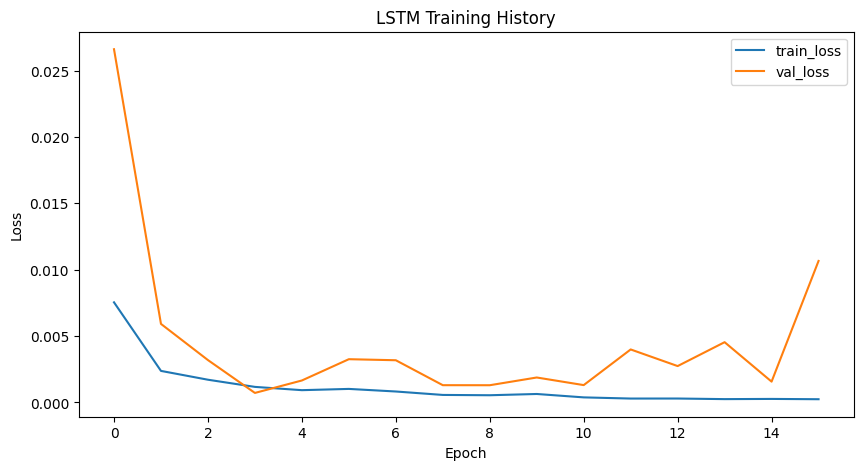

139/139 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step
RMSE: 30.1169, MAE: 27.4014


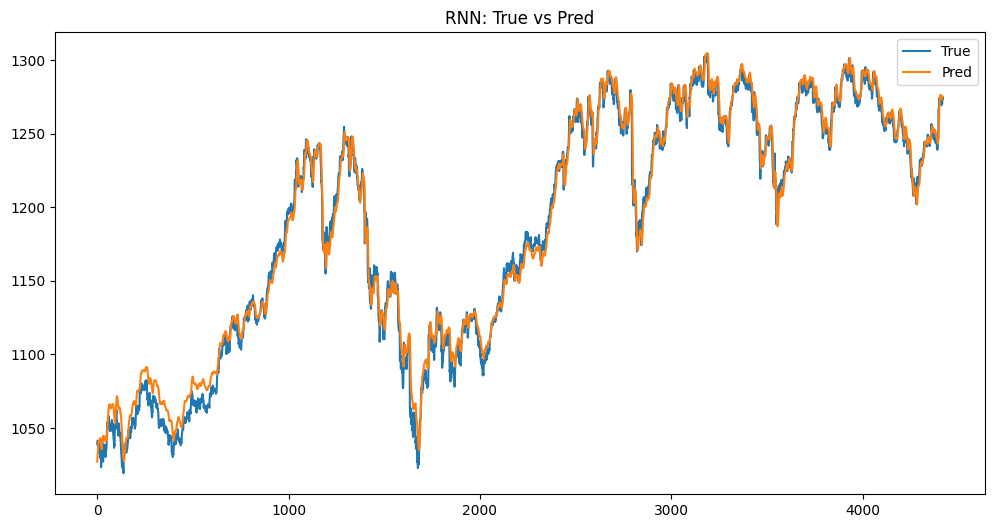

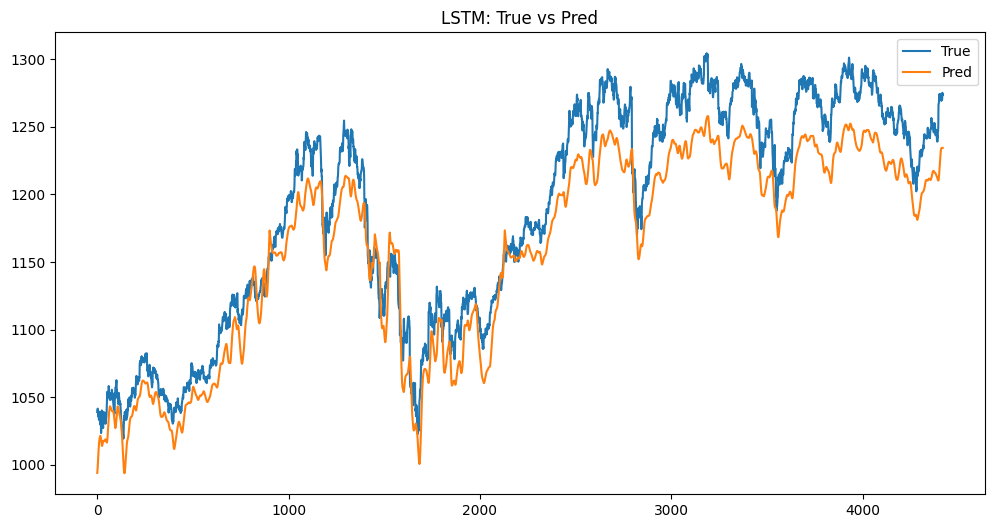

RNN overfit check:
 Có dấu hiệu overfitting: train loss tiếp tục giảm trong khi validation loss đã tăng.
Chênh lệch lớn giữa validation loss và train loss — khả năng overfitting cao.
Epoch có val_loss nhỏ nhất: 13, val_loss tại đó = 0.000170.
LSTM overfit check:
 Có dấu hiệu overfitting: train loss tiếp tục giảm trong khi validation loss đã tăng.
Chênh lệch lớn giữa validation loss và train loss — khả năng overfitting cao.
Epoch có val_loss nhỏ nhất: 3, val_loss tại đó = 0.000716.


In [9]:
# %%
# MODEL 1: STACKED SimpleRNN (>=7 layers total)
# We'll build: 4 SimpleRNN layers (some with return_sequences=True) + BatchNorm + Dropout + 2 Dense = >=7 layers

def build_rnn_model(input_shape):
    model = Sequential()
    model.add(SimpleRNN(64, return_sequences=True, input_shape=input_shape))  # 1
    model.add(BatchNormalization())
    model.add(SimpleRNN(64, return_sequences=True))  # 2
    model.add(Dropout(0.2))
    model.add(SimpleRNN(64, return_sequences=True))  # 3
    model.add(BatchNormalization())
    model.add(SimpleRNN(32, return_sequences=False))  # 4
    # now add dense layers (these count toward layers)
    model.add(Dense(32, activation='relu'))  # 5
    model.add(Dropout(0.2))
    model.add(Dense(16, activation='relu'))  # 6
    model.add(Dense(1, activation='linear'))  # 7
    model.compile(optimizer='adam', loss='mse')
    return model

rnn_model = build_rnn_model((X_train.shape[1], X_train.shape[2]))
rnn_model.summary()

# %%
# CALLBACKS
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    ModelCheckpoint('best_rnn.h5', monitor='val_loss', save_best_only=True, verbose=1)
]

# %%
# TRAIN RNN
hist_rnn = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=2
)
plot_history(hist_rnn, 'RNN Training History')

# %%
# EVALUATE RNN
y_test_unscaled_rnn, y_pred_rnn, rmse_rnn, mae_rnn = evaluate_and_report(rnn_model, X_test, y_test, scaler)

# %%
# MODEL 2: STACKED LSTM (>=7 layers total)
# We'll build: 4 LSTM layers + BatchNorm + Dropout + 2 Dense = >=7 layers

def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(128, return_sequences=True, input_shape=input_shape))  # 1
    model.add(BatchNormalization())
    model.add(LSTM(64, return_sequences=True))  # 2
    model.add(Dropout(0.2))
    model.add(LSTM(64, return_sequences=True))  # 3
    model.add(BatchNormalization())
    model.add(LSTM(32, return_sequences=False))  # 4
    model.add(Dense(32, activation='relu'))  # 5
    model.add(Dropout(0.2))
    model.add(Dense(16, activation='relu'))  # 6
    model.add(Dense(1, activation='linear'))  # 7
    model.compile(optimizer='adam', loss='mse')
    return model

lstm_model = build_lstm_model((X_train.shape[1], X_train.shape[2]))
lstm_model.summary()

# %%
# CALLBACKS for LSTM
callbacks_lstm = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, verbose=1),
    ModelCheckpoint('best_lstm.h5', monitor='val_loss', save_best_only=True, verbose=1)
]

# %%
# TRAIN LSTM
hist_lstm = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_lstm,
    verbose=2
)
plot_history(hist_lstm, 'LSTM Training History')

# %%
# EVALUATE LSTM
y_test_unscaled_lstm, y_pred_lstm, rmse_lstm, mae_lstm = evaluate_and_report(lstm_model, X_test, y_test, scaler)

# %%
# PLOT PREDICTIONS vs GROUND TRUTH

def plot_preds(y_true, y_pred, title='Predictions vs True'):
    plt.figure(figsize=(12,6))
    plt.plot(y_true, label='True')
    plt.plot(y_pred, label='Pred')
    plt.title(title)
    plt.legend()
    plt.show()

plot_preds(y_test_unscaled_rnn, y_pred_rnn, 'RNN: True vs Pred')
plot_preds(y_test_unscaled_lstm, y_pred_lstm, 'LSTM: True vs Pred')

# %%
# OVERFITTING ANALYSIS (TỰ ĐỘNG)
# Kiểm tra một số dấu hiệu cơ bản của overfitting và in ra gợi ý

def detect_overfitting(hist):
    train_losses = hist.history['loss']
    val_losses = hist.history.get('val_loss')
    if val_losses is None:
        return 'Không có validation loss để đánh giá.'
    min_val_epoch = np.argmin(val_losses)
    min_val = val_losses[min_val_epoch]
    final_train = train_losses[-1]
    final_val = val_losses[-1]
    messages = []
    # Dấu hiệu: val_loss tăng trong khi train_loss giảm
    if final_train < train_losses[0] and final_val > min_val:
        messages.append('Có dấu hiệu overfitting: train loss tiếp tục giảm trong khi validation loss đã tăng.')
    # Dấu hiệu: chênh lệch lớn giữa train và val
    if (final_val - final_train) / (abs(final_train) + 1e-8) > 0.2:
        messages.append('Chênh lệch lớn giữa validation loss và train loss — khả năng overfitting cao.')
    # Kiểm tra epoch tốt nhất
    messages.append(f'Epoch có val_loss nhỏ nhất: {min_val_epoch}, val_loss tại đó = {min_val:.6f}.')
    return '\n'.join(messages)

print('RNN overfit check:\n', detect_overfitting(hist_rnn))
print('LSTM overfit check:\n', detect_overfitting(hist_lstm))


In [11]:
# %%
# DỰ BÁO (Ví dụ): 1-step ahead (ngày tiếp theo) dùng model tốt nhất
# Chọn model tốt nhất bằng RMSE đơn giản
if rmse_rnn < rmse_lstm:
    best_model = rnn_model
    print('Chọn RNN là mô hình tốt nhất (dựa trên RMSE).')
else:
    best_model = lstm_model
    print('Chọn LSTM là mô hình tốt nhất (dựa trên RMSE).')

# Lấy sequence cuối cùng từ toàn bộ dữ liệu để dự đoán bước tiếp theo
last_sequence = scaled[-SEQUENCE_LENGTH:]
last_seq_reshaped = last_sequence.reshape((1, SEQUENCE_LENGTH, 1))
next_pred_scaled = best_model.predict(last_seq_reshaped)
next_pred = scaler.inverse_transform(next_pred_scaled).flatten()[0]
print(f'Forecast 1-step ahead (next day): {next_pred:.4f}')


Chọn RNN là mô hình tốt nhất (dựa trên RMSE).
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Forecast 1-step ahead (next day): 1275.6394


In [13]:
def multi_step_forecast(model, last_sequence_scaled, k=30, scaler=scaler):
    # nếu là numpy array, chuyển sang list
    if isinstance(last_sequence_scaled, np.ndarray):
        seq = last_sequence_scaled.copy().tolist()
    else:
        seq = last_sequence_scaled.copy()
    preds = []
    for _ in range(k):
        arr = np.array(seq[-SEQUENCE_LENGTH:]).reshape((1, SEQUENCE_LENGTH, 1))
        p = model.predict(arr, verbose=0)[0,0]
        preds.append(p)
        seq.append([p])
    preds = np.array(preds).reshape(-1,1)
    return scaler.inverse_transform(preds).flatten()

# DỰ BÁO 30 NGÀY
pred_30_days = multi_step_forecast(best_model, list(scaled), k=30)
print('Dự báo 30 ngày đầu tiên:', pred_30_days[:10])


# DỰ BÁO 1 NĂM (365 NGÀY)
pred_1_year = multi_step_forecast(best_model, list(scaled), k=365)
print('Dự báo 1 năm đầu tiên:', pred_1_year[:10])

Dự báo 30 ngày đầu tiên: [1275.6394 1276.306  1277.0219 1277.7766 1278.6342 1279.4645 1280.302
 1281.1531 1281.9922 1282.8405]
Dự báo 1 năm đầu tiên: [1275.6394 1276.306  1277.0219 1277.7766 1278.6342 1279.4645 1280.302
 1281.1531 1281.9922 1282.8405]
